[*********************100%***********************]  1 of 1 completed


Epoch 1/50
34/34 [==============================] - 1s 7ms/step - loss: 0.0188 - val_loss: 0.0027
Epoch 2/50
34/34 [==============================] - 0s 3ms/step - loss: 9.7925e-04 - val_loss: 0.0025
Epoch 3/50
34/34 [==============================] - 0s 3ms/step - loss: 7.2142e-04 - val_loss: 0.0016
Epoch 4/50
34/34 [==============================] - 0s 3ms/step - loss: 6.0071e-04 - val_loss: 0.0015
Epoch 5/50
34/34 [==============================] - 0s 3ms/step - loss: 5.5351e-04 - val_loss: 0.0014
Epoch 6/50
34/34 [==============================] - 0s 3ms/step - loss: 5.4504e-04 - val_loss: 0.0017
Epoch 7/50
34/34 [==============================] - 0s 3ms/step - loss: 5.0293e-04 - val_loss: 0.0013
Epoch 8/50
34/34 [==============================] - 0s 3ms/step - loss: 5.1292e-04 - val_loss: 0.0015
Epoch 9/50
34/34 [==============================] - 0s 3ms/step - loss: 5.0171e-04 - val_loss: 0.0011
Epoch 10/50
34/34 [==============================] - 0s 3ms/step - loss: 4.7093e-04 - 

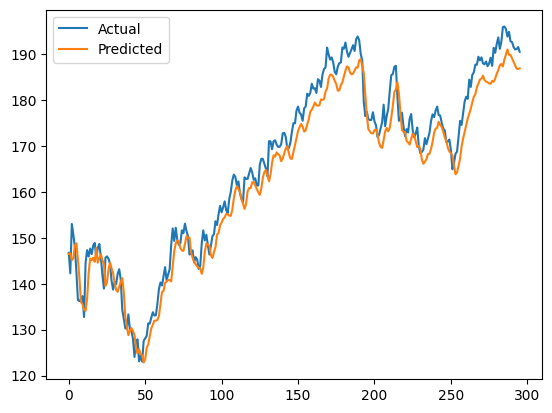

In [1]:
# rnn_stock_prediction_tf.py

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ---------- Load dataset ----------
df = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
data = df[['Close']].values

# ---------- Normalize ----------
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# ---------- Sliding Window ----------
window = 30
X, y = [], []

for i in range(window, len(data)):
    X.append(data[i-window:i])
    y.append(data[i])

X = np.array(X)
y = np.array(y)

# ---------- Train test split ----------
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ---------- Model ----------
model = Sequential([
    SimpleRNN(64, input_shape=(window,1)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early]
)

# ---------- Prediction ----------
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_real = scaler.inverse_transform(y_test)

# ---------- Metrics ----------
rmse = np.sqrt(mean_squared_error(y_test_real,pred))
mae = mean_absolute_error(y_test_real,pred)

mape = np.mean(np.abs((y_test_real - pred)/y_test_real))*100
r2 = r2_score(y_test_real,pred)

print("RMSE:",rmse)
print("MAE:",mae)
print("MAPE:",mape)
print("R2:",r2)

# ---------- Plot ----------
plt.plot(y_test_real,label="Actual")
plt.plot(pred,label="Predicted")
plt.legend()
plt.show()